# Daily Embedding Classifier — Home Ventilator Data

**Goal**: Compress each patient-day into a 32-dim embedding using a shared Transformer,
then classify label 0 vs label 1 using XGBoost / Random Forest per day.

**Pipeline**:
```
Raw readings (per 24k-row chunk per patient per unified_day)
  → Shared Transformer Encoder  (BCE loss, patient-level label)
  → 32-dim chunk embedding
  → Average chunks → 1 embedding per (patient, unified_day)
  → XGBoost / RF on 32-dim features → label 0 or 1 per row
  → Results table: rows=patients, columns=days
```

**Data**: 86 patients (patient 68 dropped), ~1/3 label 1, 7 days of ventilator readings
- unified_day 6 = earliest day (furthest from event)
- unified_day 0 = latest day  (closest to event)
- Each (patient, day) row is one independent prediction


---
## Step 1 — Install & Import

In [ ]:
!pip install -q xgboost scikit-learn

In [ ]:
import os
import gc
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.cuda.amp import GradScaler, autocast
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from collections import Counter, defaultdict
from matplotlib.colors import LinearSegmentedColormap
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')


Device : cuda
PyTorch: 2.10.0+cu128


---
## Step 2 — Mount Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ROOT = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Cleaned_Data/first7days_rawdata_label0&1_parquet"

df_train = pd.read_parquet(os.path.join(ROOT, 'train.parquet'))
df_val   = pd.read_parquet(os.path.join(ROOT, 'val.parquet'))
df_test  = pd.read_parquet(os.path.join(ROOT, 'test.parquet'))

for df in [df_train, df_val, df_test]:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df['end_date']  = pd.to_datetime(df['end_date'],  errors='coerce')

print(f'Train: {len(df_train):,}  |  Val: {len(df_val):,}  |  Test: {len(df_test):,}')
df_train.head(3)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 73,041,029  |  Val: 20,671,364  |  Test: 26,861,042


,timestamp,test_type,test_value,patient_id,label,start_date,end_date,machine_year_full,delta_time_seconds,time_from_start_seconds,patient_span_days,hour_of_day,hour_of_day_scaled,countdown_days_target,countdown_days_log_target,countdown_days_target_scaled,countdown_days_log_target_scaled,test_value_scaled,time_from_start_scaled,collection
0,2023-10-25 13:04:44.200,pressure,5.37,2,0,2023-10-25 13:04:44.200,2023-10-31 22:17:08,B3A20605023_2023_good,0.0,0.0,6.383609,13,0.541667,6,2.807355,1.0,1.0,0.027914,0.000000e+00,train
1,2023-10-25 13:04:44.200,flow,77.70,2,0,2023-10-25 13:04:44.200,2023-10-31 22:17:08,B3A20605023_2023_good,0.0,0.0,6.383609,13,0.541667,6,2.807355,1.0,1.0,0.486997,0.000000e+00,train
2,2023-10-25 13:04:44.400,flow,-37.80,2,0,2023-10-25 13:04:44.200,2023-10-31 22:17:08,B3A20605023_2023_good,0.2,0.2,6.383609,13,0.541667,6,2.807355,1.0,1.0,0.002517,3.306884e-07,train


---
## Step 3 — Fix Countdown Days, Drop Bad Patients, Trim Columns

**unified_day (0..6, 7 days)**:
- Label 1: use `countdown_days_target` directly (0..6), no dropping, no shifting
  - unified_day 0 = day of hospital admission (sparse but kept)
  - unified_day 6 = earliest day (6 days before hospital)
- Label 0: calculate days back from `end_date`
  - unified_day 6 = last day of monitoring window
  - unified_day 0 = first day of monitoring window

**Drop**: patient 68 — only 3 days of data.

**Trim**: keep only columns needed for training to save RAM.


In [ ]:
# ── Drop insufficient patients ───────────────────────────────────────────────
PATIENTS_TO_DROP = [68]
for df in [df_train, df_val, df_test]:
    mask = df['patient_id'].isin(PATIENTS_TO_DROP)
    df.drop(df[mask].index, inplace=True)
print(f'Dropped patients: {PATIENTS_TO_DROP}')

# ── Build unified_day (0..6) ──────────────────────────────────────────────────
def add_unified_day(df):
    df['unified_day'] = -1

    # Label 1: use countdown_days_target directly 0..6, keep all days
    mask1 = df['label'] == 1
    df.loc[mask1, 'unified_day'] = (
        df.loc[mask1, 'countdown_days_target'].clip(0, 6)
    ).astype(int)

    # Label 0: calculate from end_date backwards
    #   days_from_end=0 → unified_day 6 (last day)
    #   days_from_end=6 → unified_day 0 (first day)
    mask0 = df['label'] == 0
    days_from_end = (
        df.loc[mask0, 'end_date'].dt.normalize()
      - df.loc[mask0, 'timestamp'].dt.normalize()
    ).dt.days
    df.loc[mask0, 'unified_day'] = (6 - days_from_end).clip(0, 6).astype(int)

    # Drop rows outside 0..6 (label 0 day-14 placeholder rows)
    drop_idx = df[~df['unified_day'].between(0, 6)].index
    df.drop(drop_idx, inplace=True)
    df['unified_day'] = df['unified_day'].astype(int)

print('\nAdding unified_day...')
add_unified_day(df_train); gc.collect()
add_unified_day(df_val);   gc.collect()
add_unified_day(df_test);  gc.collect()

# ── NEW: Compute time_from_start_scaled ──────────────────────────────────────
# Seconds elapsed since each patient's first ever timestamp.
# Scaler fitted on train only to prevent data leakage.
from sklearn.preprocessing import MinMaxScaler

print('\nComputing time_from_start_scaled...')
for df in [df_train, df_val, df_test]:
    patient_min_ts = df.groupby('patient_id')['timestamp'].transform('min')
    df['time_from_start_seconds'] = (
        df['timestamp'] - patient_min_ts
    ).dt.total_seconds()

tfs_scaler = MinMaxScaler()
df_train['time_from_start_scaled'] = tfs_scaler.fit_transform(
    df_train[['time_from_start_seconds']])
df_val['time_from_start_scaled']   = tfs_scaler.transform(
    df_val[['time_from_start_seconds']])
df_test['time_from_start_scaled']  = tfs_scaler.transform(
    df_test[['time_from_start_seconds']])

print(f'  time_from_start_scaled range (train): '
      f'{df_train["time_from_start_scaled"].min():.4f} – '
      f'{df_train["time_from_start_scaled"].max():.4f}')

# ── Keep only columns needed — free RAM ───────────────────────────────────────
KEEP_COLS = ['patient_id', 'label', 'unified_day',
             'test_type', 'test_value_scaled', 'hour_of_day_scaled',
             'time_from_start_scaled',   # ← NEW
             'timestamp', 'collection']

for df, name in [(df_train,'train'), (df_val,'val'), (df_test,'test')]:
    drop_cols = [c for c in df.columns if c not in KEEP_COLS]
    df.drop(columns=drop_cols, inplace=True)
    df.reset_index(drop=True, inplace=True)
    gc.collect()
    print(f'{name:>6}: {len(df):,} rows  '
          f'{df.memory_usage(deep=True).sum()/1024**3:.2f} GB')

# ── Verify unified_day coverage ───────────────────────────────────────────────
all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)
print('\n=== unified_day distribution by label ===')
print(all_df.groupby(['label','unified_day']).size()
      .rename('rows').reset_index().to_string(index=False))

print('\n=== per-patient unified_day coverage ===')
print(f"{'PID':>5}  {'Lbl':>3}  {'Split':>6}  unified_days")
print('-'*55)
for pid, sub in all_df.groupby('patient_id', sort=True):
    lbl   = int(sub['label'].iloc[0])
    split = sub['collection'].iloc[0] if 'collection' in sub.columns else '?'
    days  = sorted(sub['unified_day'].unique().tolist())
    print(f'{pid:>5}  {lbl:>3}  {split:>6}  {days}')

print(f'\nTotal patients: {all_df["patient_id"].nunique()}')
print(f'Label 0: {(all_df.drop_duplicates("patient_id")["label"]==0).sum()}  '
      f'Label 1: {(all_df.drop_duplicates("patient_id")["label"]==1).sum()}')


Dropped patients: [68]

Adding unified_day...
 train: 71,871,971 rows  10.51 GB
   val: 20,671,364 rows  2.98 GB
  test: 26,861,042 rows  3.90 GB

=== unified_day distribution by label ===
 label  unified_day     rows
     0            0 15609482
     0            1 10484170
     0            2 10331909
     0            3  8405382
     0            4 10450702
     0            5  9457101
     0            6  8723024
     1            0  7683053
     1            1  6181350
     1            2  6634248
     1            3  6374367
     1            4  7176347
     1            5  6199971
     1            6  5693271

=== per-patient unified_day coverage ===
  PID  Lbl   Split  unified_days
-------------------------------------------------------
    1    0    test  [0, 1, 2, 3, 4, 5, 6]
    2    0   train  [0, 1, 2, 3, 4, 5, 6]
    3    0   train  [0, 1, 2, 3, 4, 5, 6]
    4    0     val  [0, 1, 2, 3, 4, 5, 6]
    5    0     val  [0, 1, 2, 4, 5, 6]
    6    0   train  [0, 1, 2, 3, 4, 5,

---
## Step 4 — Label Encoder for test_type

In [ ]:
uniq_types   = np.union1d(df_train['test_type'].unique(),
                            df_val['test_type'].unique())
le_test_type = LabelEncoder().fit(uniq_types)

NUM_REAL_TYPES = len(le_test_type.classes_)
PAD_TYPE_ID    = NUM_REAL_TYPES
VOCAB_SIZE     = NUM_REAL_TYPES + 1

print(f'test_type classes : {le_test_type.classes_}')
print(f'PAD_TYPE_ID       : {PAD_TYPE_ID}')
print(f'VOCAB_SIZE         : {VOCAB_SIZE}')


test_type classes : ['flow' 'pressure']
PAD_TYPE_ID       : 2
VOCAB_SIZE         : 3


---
## Step 5 — Dataset: 24,000-row chunks

Groups by `(patient_id, unified_day)`. Each day split into 24,000-row chunks
(~40 min, same as regression model). Each chunk = one training sample.
At embedding extraction: average all chunks per patient-day → 1 embedding per day.

`BATCH_SIZE=1` — required because 24k tokens × attention matrix ≈ 9GB on A100.
Mixed precision (float16) halves GPU memory.


In [ ]:
class PatientDayDataset(Dataset):
    """
    Groups by (patient_id, unified_day), splits into 24k-row chunks.
    Each chunk = one training sample.
    Embeddings are averaged across chunks per patient-day at extraction time.
    """
    def __init__(self, df, le_test_type, chunk_size=24000):
        self.df      = df
        self.le      = le_test_type
        self.samples = []   # (patient_id, unified_day, label, chunk_id, row_indices)

        for (pid, uday), sub in df.groupby(
                ['patient_id', 'unified_day'], sort=False):
            label = int(sub['label'].iloc[0])
            sub   = sub.sort_values('timestamp')
            idx   = sub.index.to_numpy()

            for chunk_id, start in enumerate(range(0, len(idx), chunk_size)):
                chunk_idx = idx[start: start + chunk_size]
                if len(chunk_idx) == 0:
                    continue
                self.samples.append((pid, int(uday), label, chunk_id, chunk_idx))

        n_patients   = df['patient_id'].nunique()
        label_counts = Counter(s[2] for s in self.samples)
        cday_counts  = Counter(s[1] for s in self.samples)
        print(f'  Built: {len(self.samples)} chunks from {n_patients} patients')
        print(f'  Label 0 chunks: {label_counts[0]}  |  '
              f'Label 1 chunks: {label_counts[1]}')
        print(f'  Chunks per unified_day:')
        for d in range(7):
            print(f'    day {d}: {cday_counts.get(d, 0)} chunks')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        pid, uday, label, chunk_id, idx = self.samples[i]
        sub = self.df.loc[idx]

        raw_types  = sub['test_type'].values
        known_mask = np.isin(raw_types, self.le.classes_)
        type_ids   = np.full(len(raw_types), PAD_TYPE_ID, dtype=np.int64)
        if known_mask.any():
            type_ids[known_mask] = self.le.transform(raw_types[known_mask])

        return {
            'patient_id':      pid,
            'unified_day':     uday,
            'chunk_id':        chunk_id,
            'label':           torch.tensor(label, dtype=torch.float32),
            'test_type':       torch.tensor(type_ids, dtype=torch.long),
            'test_value':      torch.tensor(
                sub['test_value_scaled'].values.astype(np.float32)),
            'hour':            torch.tensor(
                sub['hour_of_day_scaled'].values.astype(np.float32)),
            'time_from_start': torch.tensor(          # ← NEW
                sub['time_from_start_scaled'].values.astype(np.float32)),
        }


def collate_patient_day(batch):
    tt  = [s['test_type']       for s in batch]
    tv  = [s['test_value']      for s in batch]
    ho  = [s['hour']            for s in batch]
    tfs = [s['time_from_start'] for s in batch]   # ← NEW

    test_type       = pad_sequence(tt,  batch_first=True,
                                   padding_value=PAD_TYPE_ID).long()
    test_value      = pad_sequence(tv,  batch_first=True, padding_value=0.0).float()
    hour            = pad_sequence(ho,  batch_first=True, padding_value=0.0).float()
    time_from_start = pad_sequence(tfs, batch_first=True, padding_value=0.0).float()  # ← NEW

    lengths      = torch.tensor([len(t) for t in tt], dtype=torch.long)
    T            = test_type.size(1)
    padding_mask = ~(torch.arange(T).unsqueeze(0) < lengths.unsqueeze(1))

    return {
        'test_type':       test_type,
        'test_value':      test_value,
        'hour':            hour,
        'time_from_start': time_from_start,   # ← NEW
        'padding_mask':    padding_mask,
        'label':           torch.stack([s['label']       for s in batch]),
        'patient_id':      [s['patient_id']  for s in batch],
        'unified_day':     [s['unified_day'] for s in batch],
        'chunk_id':        [s['chunk_id']    for s in batch],
    }


CHUNK_SIZE = 24000
BATCH_SIZE = 1

print('Building datasets...')
train_ds = PatientDayDataset(df_train, le_test_type, chunk_size=CHUNK_SIZE)
print()
val_ds   = PatientDayDataset(df_val,   le_test_type, chunk_size=CHUNK_SIZE)
print()
test_ds  = PatientDayDataset(df_test,  le_test_type, chunk_size=CHUNK_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_patient_day, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_patient_day, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_patient_day, num_workers=2)

print('\n=== Label distribution per split ===')
for name, ds in [('train', train_ds), ('val', val_ds), ('test', test_ds)]:
    labels = [s[2] for s in ds.samples]
    n0, n1 = labels.count(0), labels.count(1)
    print(f'  {name:>6}: total={len(labels):>5}  '
          f'label 0={n0:>4}  label 1={n1:>4}  ratio={n0/max(n1,1):.2f}')

batch = next(iter(train_loader))
print(f'\nSample batch:')
print(f'  test_type shape       : {batch["test_type"].shape}')
print(f'  time_from_start shape : {batch["time_from_start"].shape}')  # ← NEW
print(f'  label                 : {batch["label"]}')
print(f'  unified_day           : {batch["unified_day"]}')


Building datasets...
  Built: 3170 chunks from 48 patients
  Label 0 chunks: 1808  |  Label 1 chunks: 1362
  Chunks per unified_day:
    day 0: 640 chunks
    day 1: 429 chunks
    day 2: 470 chunks
    day 3: 390 chunks
    day 4: 456 chunks
    day 5: 423 chunks
    day 6: 362 chunks

  Built: 913 chunks from 15 patients
  Label 0 chunks: 531  |  Label 1 chunks: 382
  Chunks per unified_day:
    day 0: 153 chunks
    day 1: 135 chunks
    day 2: 130 chunks
    day 3: 127 chunks
    day 4: 155 chunks
    day 5: 112 chunks
    day 6: 101 chunks

  Built: 1195 chunks from 22 patients
  Label 0 chunks: 936  |  Label 1 chunks: 259
  Chunks per unified_day:
    day 0: 222 chunks
    day 1: 172 chunks
    day 2: 149 chunks
    day 3: 143 chunks
    day 4: 163 chunks
    day 5: 165 chunks
    day 6: 181 chunks

=== Label distribution per split ===
   train: total= 3170  label 0=1808  label 1=1362  ratio=1.33
     val: total=  913  label 0= 531  label 1= 382  ratio=1.39
    test: total= 1195 

---
## Step 6 — Model: Shared Transformer Encoder → 32-dim Embedding

- type_emb + value_fc + **Time2Vec(hour)** + **Time2Vec(time_from_start)** → fused token [B, T, 32]
- `Time2Vec` (Kazemi et al., 2019): one linear trend term + learnable sinusoids — captures both trend and periodicity in continuous time signals
- Positional encoding (max_len=30000)
- Transformer encoder (2 layers, 4 heads, 128 FFN dim)
- Mean-pool over valid tokens → 32-dim embedding
- Linear classifier head (BCE training only, discarded at inference)


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=30000):
        super().__init__()
        pe  = torch.zeros(max_len, embed_dim)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, embed_dim, 2).float()
                        * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class Time2Vec(nn.Module):
    """
    Learnable time encoding (Kazemi et al., 2019).
      t2v(t) = [w0*t + b0,  sin(w1*t + b1), ..., sin(w_{D-1}*t + b_{D-1})]
    One linear trend term + (embed_dim - 1) learnable sinusoids.
    Input : scalar time feature  [B, T]
    Output: time embedding        [B, T, embed_dim]
    """
    def __init__(self, embed_dim: int):
        super().__init__()
        assert embed_dim >= 2, 'Time2Vec needs embed_dim >= 2'
        self.linear   = nn.Linear(1, 1)               # trend term
        self.periodic = nn.Linear(1, embed_dim - 1)   # periodic terms

    def forward(self, x):                             # x: [B, T]
        x   = x.unsqueeze(-1)                         # [B, T, 1]
        lin = self.linear(x)                          # [B, T, 1]
        per = torch.sin(self.periodic(x))             # [B, T, D-1]
        return torch.cat([lin, per], dim=-1)          # [B, T, D]


class DayEmbeddingTransformer(nn.Module):
    def __init__(self, vocab_size, pad_type_id, embed_dim=32,
                 nhead=4, num_layers=2, hidden_dim=128, dropout=0.2):
        super().__init__()
        assert embed_dim % nhead == 0
        self.pad_type_id = pad_type_id

        # Token feature projections
        self.type_emb  = nn.Embedding(vocab_size, embed_dim,
                                       padding_idx=pad_type_id)
        self.value_fc  = nn.Linear(1, embed_dim)

        # Time2Vec encodings (replaces plain linear hour_fc)
        self.hour_t2v  = Time2Vec(embed_dim)   # within-day time
        self.tfs_t2v   = Time2Vec(embed_dim)   # ← NEW: time from patient start

        self.input_norm = nn.LayerNorm(embed_dim)
        self.input_drop = nn.Dropout(dropout)
        self.pos_enc    = PositionalEncoding(embed_dim, max_len=30000)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead,
            dim_feedforward=hidden_dim,
            dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.embed_proj = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.Tanh())

        self.classifier = nn.Linear(embed_dim, 1)

    def forward(self, test_type, test_value, hour,
                time_from_start, padding_mask):      # ← time_from_start added
        x = (self.type_emb(test_type)               # [B, T, D]
             + self.value_fc(test_value.unsqueeze(-1))
             + self.hour_t2v(hour)                  # Time2Vec for hour
             + self.tfs_t2v(time_from_start))       # ← NEW: Time2Vec for tfs
        x = self.input_drop(self.input_norm(x))
        x = self.pos_enc(x)
        x = self.encoder(x, src_key_padding_mask=padding_mask)

        valid  = (~padding_mask).unsqueeze(-1).float()
        pooled = (x * valid).sum(1) / valid.sum(1).clamp(min=1)

        embedding = self.embed_proj(pooled)
        logit     = self.classifier(embedding)
        return embedding, logit


model = DayEmbeddingTransformer(
    vocab_size=VOCAB_SIZE, pad_type_id=PAD_TYPE_ID,
    embed_dim=32, nhead=4, num_layers=2, hidden_dim=128, dropout=0.2
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(model)


Model parameters: 26,849
DayEmbeddingTransformer(
  (type_emb): Embedding(3, 32, padding_idx=2)
  (value_fc): Linear(in_features=1, out_features=32, bias=True)
  (hour_fc): Linear(in_features=1, out_features=32, bias=True)
  (input_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (input_drop): Dropout(p=0.2, inplace=False)
  (pos_enc): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=Fals

---
## Step 7 — Training

BCE loss with pos_weight for class imbalance.
Mixed precision (float16) to reduce GPU memory.
Monitors val AUROC — saves best model checkpoint.


In [ ]:
train_labels = [s[2] for s in train_ds.samples]
n_pos        = sum(train_labels)
n_neg        = len(train_labels) - n_pos
pos_weight   = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f'Train chunks — Label 0: {n_neg}  |  Label 1: {n_pos}')
print(f'pos_weight: {pos_weight.item():.3f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10)
scaler = GradScaler()

SAVE_DIR        = "/content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_first7days_32dim"
os.makedirs(SAVE_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(SAVE_DIR, 'best_day_embedding_transformer.pth')
print(f'Save dir: {SAVE_DIR}')

# ── Pre-training debug ────────────────────────────────────────────────────────
model.train()
_b  = next(iter(train_loader))
with torch.no_grad():
    _, _logit = model(
        _b['test_type'].to(device),
        _b['test_value'].to(device),
        _b['hour'].to(device),
        _b['time_from_start'].to(device),   # ← NEW
        _b['padding_mask'].to(device))
_probs = _logit.squeeze(1).sigmoid()
print('\n=== Pre-training debug ===')
print(f'Labels      : {_b["label"].tolist()}')
print(f'Logits      : {[round(x,3) for x in _logit.squeeze(1).tolist()]}')
print(f'Probs       : {[round(x,3) for x in _probs.tolist()]}')
print(f'Loss        : {criterion(_logit.squeeze(1), _b["label"].to(device)).item():.4f}')
print('='*30)


def run_epoch(loader, model, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss, all_logits, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            tt  = batch['test_type'].to(device)
            tv  = batch['test_value'].to(device)
            ho  = batch['hour'].to(device)
            tfs = batch['time_from_start'].to(device)   # ← NEW
            pm  = batch['padding_mask'].to(device)
            lbl = batch['label'].to(device)

            with autocast():
                _, logit = model(tt, tv, ho, tfs, pm)   # ← tfs passed
                loss = criterion(logit.squeeze(1), lbl)

            if train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * len(lbl)
            all_logits.append(logit.squeeze(1).detach().float().cpu())
            all_labels.append(lbl.cpu())

    all_logits = torch.cat(all_logits).sigmoid().numpy()
    all_labels = torch.cat(all_labels).numpy()
    avg_loss   = total_loss / len(all_labels)
    try:    auroc = roc_auc_score(all_labels, all_logits)
    except: auroc = float('nan')
    return avg_loss, auroc


NUM_EPOCHS     = 100
EARLY_STOP_PAT = 10
best_val_auroc = 0.0
early_stop_cnt = 0
train_losses, val_losses = [], []
train_aurocs, val_aurocs = [], []

print(f'\nTraining for up to {NUM_EPOCHS} epochs...\n')
print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Train AUC":>9}  '
      f'{"Val Loss":>8}  {"Val AUC":>7}  {"":>10}')
print('-' * 62)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_auc = run_epoch(train_loader, model, optimizer,
                                criterion, train=True)
    va_loss, va_auc = run_epoch(val_loader, model, optimizer,
                                criterion, train=False)

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_aurocs.append(tr_auc);  val_aurocs.append(va_auc)

    scheduler.step(va_auc if not np.isnan(va_auc) else 0.0)

    marker = ''
    if (not np.isnan(va_auc)) and va_auc > best_val_auroc:
        best_val_auroc = va_auc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        early_stop_cnt = 0
        marker = '✅ saved'
    else:
        early_stop_cnt += 1
        if early_stop_cnt >= EARLY_STOP_PAT:
            print(f'\nEarly stopping at epoch {epoch}')
            break

    va_str = f'{va_auc:.4f}' if not np.isnan(va_auc) else '   nan'
    print(f'{epoch:>6}  {tr_loss:>10.4f}  {tr_auc:>9.4f}  '
          f'{va_loss:>8.4f}  {va_str:>7}  {marker}')

print(f'\nBest val AUROC: {best_val_auroc:.4f}')


Train chunks — Label 0: 1808  |  Label 1: 1362
pos_weight: 1.327
Save dir: /content/drive/My Drive/Monmouth_University/2025_RA/Medical_AI/Best_Model/daily_embedding_classifier_last7days_32dim

=== Pre-training debug ===
Labels      : [0.0]
Logits      : [0.304]
Probs       : [0.575]
Loss        : 0.8564

Training for up to 100 epochs...

 Epoch  Train Loss  Train AUC  Val Loss  Val AUC            
--------------------------------------------------------------
     1      1.1208     0.4967    1.2939   0.4983  ✅ saved
     2      1.1770     0.5053    1.1557   0.5019  ✅ saved
     3      1.1822     0.4839    1.0962   0.4994  
     4      1.1821     0.4817    1.1233   0.6205  ✅ saved
     5      1.1116     0.5593    1.0517   0.5837  
     6      1.0937     0.5830    1.0661   0.6100  
     7      1.1025     0.5747    0.9969   0.5463  
     8      1.0876     0.5654    1.0705   0.5737  
     9      1.0775     0.5701    1.0532   0.6074  
    10      1.0406     0.5861    1.1614   0.5903  
    1

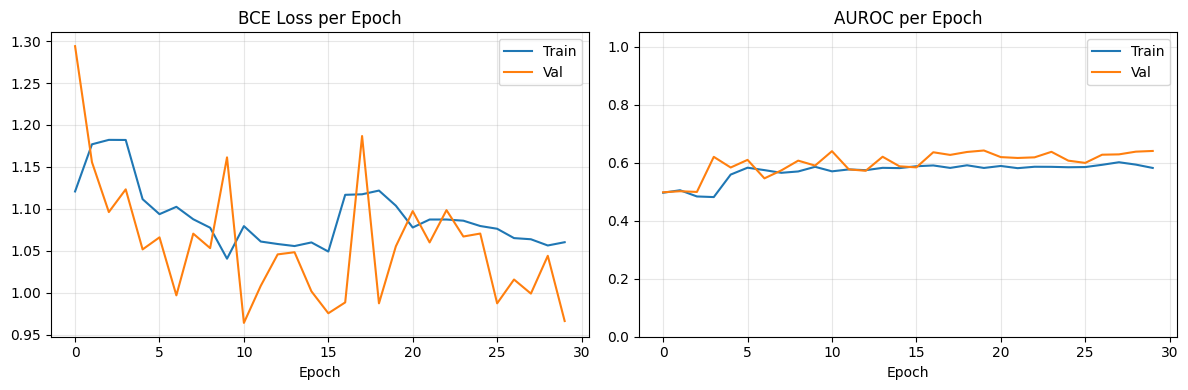

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses,   label='Val')
axes[0].set_title('BCE Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(train_aurocs, label='Train')
axes[1].plot(val_aurocs,   label='Val')
axes[1].set_title('AUROC per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
plt.show()


---
## Step 8 — Extract Day Embeddings from Best Model

Load best checkpoint. For each (patient, unified_day):
- Run all 24k-row chunks through transformer
- Average chunk embeddings → one 32-dim vector per patient-day

Result: one row per (patient, unified_day) with columns emb_0..emb_31


In [ ]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()
print('Best model loaded.')


def extract_embeddings(loader, model, device):
    """
    One row per (patient_id, unified_day).
    Multiple chunks averaged into one embedding per patient-day.
    """
    accum = defaultdict(lambda: {'embs': [], 'label': None})

    with torch.no_grad():
        for batch in loader:
            tt  = batch['test_type'].to(device)
            tv  = batch['test_value'].to(device)
            ho  = batch['hour'].to(device)
            tfs = batch['time_from_start'].to(device)   # ← NEW
            pm  = batch['padding_mask'].to(device)

            with autocast():
                emb, _ = model(tt, tv, ho, tfs, pm)    # ← tfs passed
            emb_np = emb.float().cpu().numpy()

            for j in range(len(batch['label'])):
                key = (batch['patient_id'][j], batch['unified_day'][j])
                accum[key]['embs'].append(emb_np[j])
                accum[key]['label'] = int(batch['label'][j].item())

    records = []
    for (pid, uday), val in accum.items():
        mean_emb = np.mean(val['embs'], axis=0)
        row = {'patient_id': pid, 'unified_day': uday, 'label': val['label']}
        for k, v in enumerate(mean_emb):
            row[f'emb_{k}'] = float(v)
        records.append(row)

    return (pd.DataFrame(records)
            .sort_values(['patient_id', 'unified_day'])
            .reset_index(drop=True))


print('Extracting embeddings...')
emb_train = extract_embeddings(train_loader, model, device)
emb_val   = extract_embeddings(val_loader,   model, device)
emb_test  = extract_embeddings(test_loader,  model, device)

print(f'Train: {emb_train.shape}  Val: {emb_val.shape}  Test: {emb_test.shape}')
print(f'Unified days: {sorted(emb_train.unified_day.unique().tolist())}')
emb_train.head(8)


Best model loaded.
Extracting embeddings...
Train: (325, 35)  Val: (100, 35)  Test: (151, 35)
Unified days: [0, 1, 2, 3, 4, 5, 6]


,patient_id,unified_day,label,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31
0,2,0,0,-0.999512,0.624372,-0.546108,0.075858,0.360456,-0.991002,-0.075553,...,0.999512,0.028100,-1.000000,-0.999581,-0.048418,-0.998047,-0.966309,-0.616002,0.997559,0.981655
1,2,1,0,-0.999512,0.623535,-0.544841,0.076976,0.359782,-0.990967,-0.075216,...,0.999512,0.028758,-1.000000,-0.999593,-0.047974,-0.998047,-0.966146,-0.616130,0.997559,0.981527
2,2,2,0,-0.749878,0.518936,-0.440491,0.046989,0.276733,-0.745300,-0.051941,...,0.749939,0.005667,-0.750183,-0.749756,-0.032169,-0.749329,-0.729126,-0.513077,0.748840,0.739563
3,2,3,0,-0.999512,0.634277,-0.556641,0.067139,0.366455,-0.991699,-0.077637,...,0.999512,0.023956,-1.000000,-1.000000,-0.051849,-0.998047,-0.967773,-0.615723,0.997559,0.982910
4,2,4,0,-0.999512,0.622721,-0.543864,0.077983,0.359090,-0.990967,-0.074870,...,0.999512,0.029310,-1.000000,-0.999512,-0.047557,-0.998047,-0.966064,-0.616211,0.997559,0.981445
5,2,5,0,-0.999512,0.623814,-0.545131,0.076817,0.359898,-0.991071,-0.075221,...,0.999512,0.028676,-1.000000,-0.999581,-0.048048,-0.998047,-0.966239,-0.616211,0.997559,0.981515
6,2,6,0,-0.999512,0.623535,-0.545061,0.076904,0.359759,-0.991002,-0.075239,...,0.999512,0.028658,-1.000000,-0.999581,-0.048056,-0.998047,-0.966239,-0.616141,0.997559,0.981585
7,3,0,0,-0.440469,0.362905,-0.284395,0.038340,0.158999,-0.437988,-0.022391,...,0.440391,-0.007772,-0.440469,-0.440059,-0.007723,-0.441133,-0.429395,-0.394308,0.440879,0.434902


In [ ]:
emb_train.to_parquet(os.path.join(SAVE_DIR, 'emb_train.parquet'), index=False)
emb_val.to_parquet(  os.path.join(SAVE_DIR, 'emb_val.parquet'),   index=False)
emb_test.to_parquet( os.path.join(SAVE_DIR, 'emb_test.parquet'),  index=False)
print('Embeddings saved.')


Embeddings saved.


---
## Step 11 — PCA of Embedding Space

Visualise whether label 0 and label 1 patient-days cluster separately
in the 32-dim embedding space.


In [ ]:
all_emb = pd.concat([emb_train, emb_val, emb_test], ignore_index=True)
X_pca   = all_emb[EMB_COLS].values
y_pca   = all_emb['label'].values
ud_pca  = all_emb['unified_day'].values

pca = PCA(n_components=2, random_state=42)
Z   = pca.fit_transform(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for lbl, name, colour in [
    (0, 'Label 0 (healthy)',  '#3B8BD4'),
    (1, 'Label 1 (hospital)', '#D85A30'),
]:
    mask = y_pca == lbl
    axes[0].scatter(Z[mask,0], Z[mask,1], c=colour,
                    alpha=0.5, s=20, label=name)
axes[0].set_title('PCA — by label')
axes[0].legend(); axes[0].grid(alpha=0.3)

sc = axes[1].scatter(Z[:,0], Z[:,1], c=ud_pca,
                     cmap='Blues', alpha=0.5, s=20)
plt.colorbar(sc, ax=axes[1], label='Unified day (0=latest, 6=earliest)')
axes[1].set_title('PCA — by unified day')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'pca_embeddings.png'), dpi=150)
plt.show()
print(f'PCA explained variance: {pca.explained_variance_ratio_.round(3)}')


---
## Summary

| Output | Description |
|--------|-------------|
| `best_day_embedding_transformer.pth` | Trained shared transformer |
| `emb_train/val/test.parquet` | 32-dim embeddings per (patient, unified_day) |
| `training_curves.png` | Loss & AUROC per epoch |
| `confusion_matrices.png` | 2×3 confusion matrices (blue heatmap) |
| `pca_embeddings.png` | 2D projection of embedding space |
| `tbl_te_x` / `tbl_te_r` | Patient × day results table (test set) |

**Results table format:**
```
patient_id | true_label | day_0 | day_1 | day_2 | day_3 | day_4 | day_5 | day_6
     2     |     0      |   0   |   0   |   0   |   0   |   0   |   0   |   0
    58     |     1      |   -   |   1   |   1   |   0   |   1   |   1   |   1
```

**Next step**: combine with regression model:
- Label 0 → countdown = fixed (healthy)
- Label 1 → run regression transformer → predicted days remaining
